In [29]:
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [9]:
root_data = Path("./data")

keywords = ["data", "queich"]
csv_paths = [
    f for f in root_data.rglob("*.csv") 
    if any(k in f.name for k in keywords)
    ]
csv_paths

[WindowsPath('data/abfluss_queich_siebeldingen/data/abfluss_queich_siebeldingen.csv'),
 WindowsPath('data/precipitation_dahn/data/data_OBS_DEU_P1D_RR.csv'),
 WindowsPath('data/precipitation_pirmasens/data/data_3939.csv'),
 WindowsPath('data/snow_bad_bergzabern/data/data_OBS_DEU_P1D_SH.csv'),
 WindowsPath('data/snow_dahn/data/data_OBS_DEU_P1D_SH-N_19797.csv'),
 WindowsPath('data/snow_pirmasens/data/data_OBS_DEU_P1D_SH.csv'),
 WindowsPath('data/temp_mean_2m_pirmasens/data/data_3939.csv')]

In [10]:
df_dict = {p.parent.parent.stem: pd.read_csv(filepath_or_buffer=p, sep=",", index_col=False) for p in csv_paths}

In [11]:
df_queich = df_dict["abfluss_queich_siebeldingen"]
df_discharge = df_queich[df_queich["Parameter"] == "Abfluss am Pegel"]


In [12]:
df_series_dict = {}
for key, df in df_dict.items():
    if key != "abfluss_queich_siebeldingen":
        df_series = pd.Series(df["Wert"].values, index=df["Zeitstempel"])
        df_series.index = pd.to_datetime(df_series.index)
        df_series_dict[key] = df_series
        
    if key == "abfluss_queich_siebeldingen":
        df_series = pd.Series(df["Wert"].values, index=df["Datum"])
        df_series.index = pd.to_datetime(df_series.index, format="%d.%m.%Y")
        df_series_dict[key] = df_series

In [13]:
df_series_dict.keys()

dict_keys(['abfluss_queich_siebeldingen', 'precipitation_dahn', 'precipitation_pirmasens', 'snow_bad_bergzabern', 'snow_dahn', 'snow_pirmasens', 'temp_mean_2m_pirmasens'])

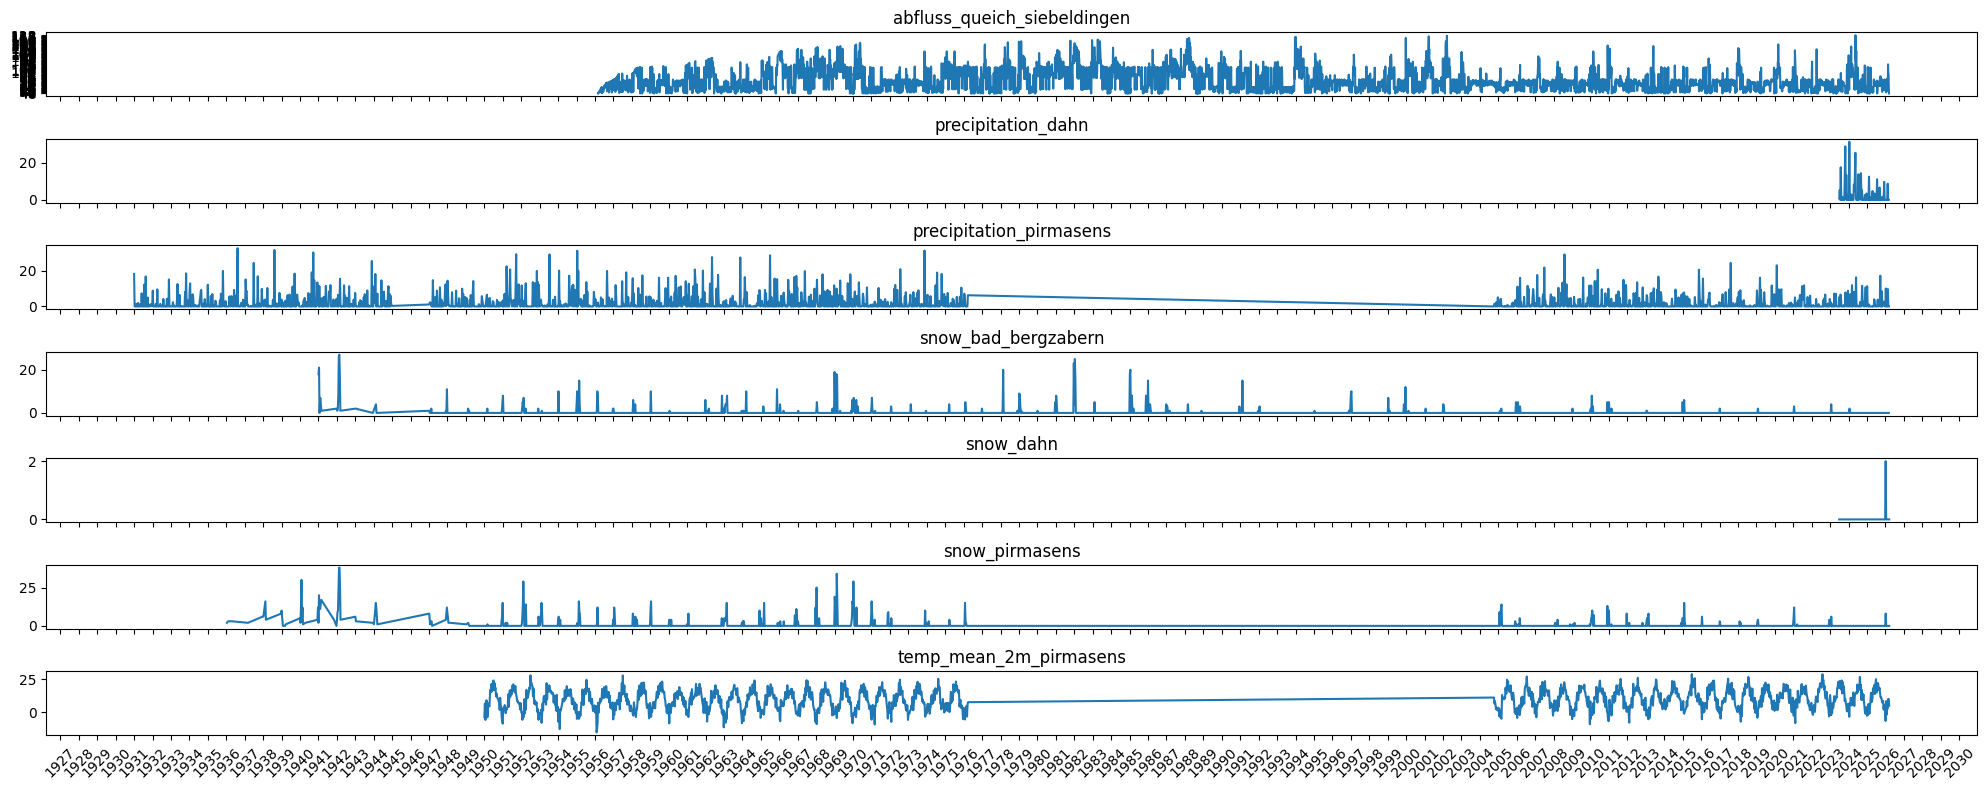

In [15]:
nrows = len(df_series_dict.keys())

fig, ax = plt.subplots(nrows=nrows, figsize=(20, 8), sharex=True)
# ax = ax.flatten()

for i, (key, df) in enumerate(df_series_dict.items()):
    df = df[::10]
    
    ax[i].plot(df)

    # Set monthly ticks
    ax[i].xaxis.set_major_locator(mdates.YearLocator())
    ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    ax[i].tick_params(axis="x", rotation=45)
    
    ax[i].set_title(key)

plt.tight_layout()
plt.show()

Evapotransp Raster

In [18]:
root_data = Path("./data")

keywords = ["data", "evapo"]
pet_paths = [
    f for f in root_data.rglob("*.asc") 
    if any(k in f.name for k in keywords)
    ]
# pet_paths

(866, 654)
{'driver': 'AAIGrid', 'dtype': 'int32', 'nodata': -9999.0, 'width': 654, 'height': 866, 'count': 1, 'crs': None, 'transform': Affine(1000.0, 0.0, 3280414.0,
       0.0, -1000.0, 6103501.0), 'blockxsize': 654, 'blockysize': 1, 'tiled': False}


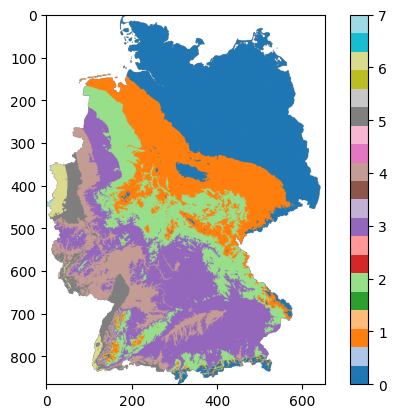

In [42]:
path = pet_paths[0]
with rasterio.open(path) as src:
    data = src.read(1)   # read first (and usually only) band
    profile = src.profile

print(data.shape)
print(profile)

# nodata
nodata = src.nodata
data = np.where(data == nodata, np.nan, data)

plt.imshow(data, cmap="tab20")
plt.colorbar()

In [37]:
data

array([[-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       ...,
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999]],
      shape=(866, 654), dtype=int32)

In [34]:
unique, counts = np.unique(data, return_counts=True)
counts

array([205511,    461,   3821,  65382,  51802,  43488,  44284,  34518,
        24510,  23972,  22143,  25086,  15462,   2839,   2126,    945,
           14])